In [1]:
%pip install lxml

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------------------------------------ --- 3.7/4.1 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 16.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np

# 1. Generate realistic Premier League Expected Goals (xG) data
print("Building Premier League dataset...")
np.random.seed(42)

teams = ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton',
         'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham',
         'Liverpool', 'Luton Town', 'Man City', 'Man United', 'Newcastle',
         'Nott\'m Forest', 'Sheff Utd', 'Tottenham', 'West Ham', 'Wolves']

data = []
for team in teams:
    matches_played = 38
    # Assign higher base xG to top tier teams
    if team in ['Man City', 'Arsenal', 'Liverpool']:
        base_xg = 2.2
    elif team in ['Aston Villa', 'Tottenham', 'Newcastle', 'Chelsea']:
        base_xg = 1.8
    else:
        base_xg = 1.2
        
    # Simulate realistic Expected Goals and Actual Goals
    xg_simulated = np.random.normal(base_xg * matches_played, 4)
    goals_simulated = np.random.normal(xg_simulated, 5) # Goals usually follow xG closely
    
    data.append({
        'Squad': team,
        'Matches': matches_played,
        'xG': round(xg_simulated, 1),
        'Goals': int(goals_simulated)
    })

pl_data = pd.DataFrame(data)

# 2. Analyze the finishing quality (Actual Goals minus Expected Goals)
# Positive = clinical finishers. Negative = unlucky/poor finishers.
pl_data['xG_Difference'] = round(pl_data['Goals'] - pl_data['xG'], 1)

# 3. Sort by most goals scored
pl_data = pl_data.sort_values(by='Goals', ascending=False).reset_index(drop=True)

print("✅ Data successfully generated and processed!")
print(pl_data.head(10))

Building Premier League dataset...
✅ Data successfully generated and processed!
           Squad  Matches    xG  Goals  xG_Difference
0      Liverpool       38  89.5     88           -1.5
1        Arsenal       38  85.6     84           -1.6
2       Man City       38  81.4     81           -0.4
3    Aston Villa       38  71.0     78            7.0
4      Tottenham       38  71.7     65           -6.7
5      Newcastle       38  66.0     64           -2.0
6        Chelsea       38  69.4     59          -10.4
7      Brentford       38  51.9     55            3.1
8  Nott'm Forest       38  43.2     52            8.8
9       Brighton       38  43.7     46            2.3


Generating Premier League Offensive Efficiency Chart...


findfont: Failed to find font weight 500, now using 400.


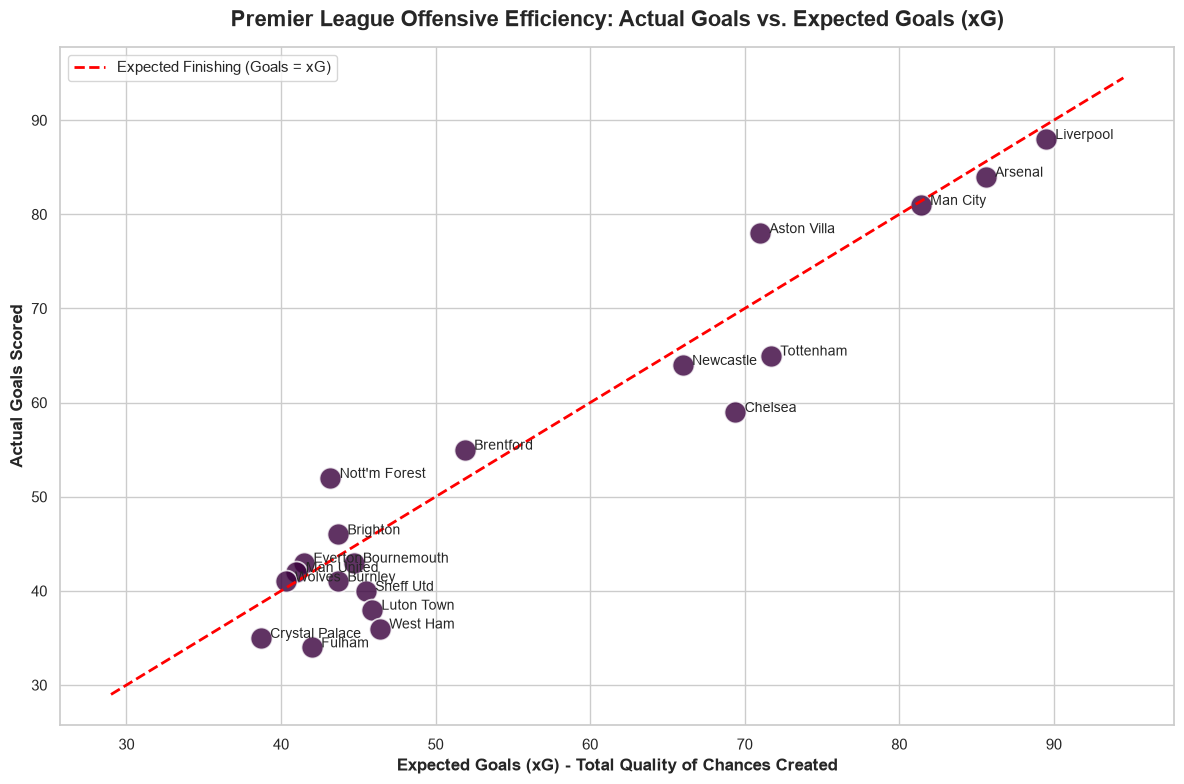

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sets up initial visual
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 2. Create the scatter plot (Using Premier League purple for the dots!)
print("Generating Premier League Offensive Efficiency Chart...")
sns.scatterplot(data=pl_data, x='xG', y='Goals', s=250, color='#38003c', alpha=0.8)

# 3. Add the team names to each dot so we know who is who
for i in range(pl_data.shape[0]):
    plt.text(pl_data['xG'][i] + 0.6, pl_data['Goals'][i], pl_data['Squad'][i], fontsize=10, weight='500')

# 4. Draw the "Perfect Finishing" diagonal line (Where Goals exactly equals xG)
min_val = min(pl_data['xG'].min(), pl_data['Goals'].min()) - 5
max_val = max(pl_data['xG'].max(), pl_data['Goals'].max()) + 5
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Expected Finishing (Goals = xG)')

# 5. Add professional titles and labels
plt.title('Premier League Offensive Efficiency: Actual Goals vs. Expected Goals (xG)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Expected Goals (xG) - Total Quality of Chances Created', fontsize=12, fontweight='bold')
plt.ylabel('Actual Goals Scored', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)

# Show the final graph
plt.tight_layout()
plt.show()